# Validación de Fotometría

Esta libreta verifica el módulo de fotometría paso a paso:
1. Resolución automática del objetivo (WCS con astrometry.net)
2. Detección de fuentes y selección de comparadoras
3. Inspección visual de aperturas sobre el frame de referencia
4. Ejecución del pipeline completo y visualización de la curva de luz diferencial

In [2]:
from pathlib import Path
import sys
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# --- Carga de variables de entorno desde .env ---
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    # Fallback sin python-dotenv: leer .env manualmente
    _env_file = Path.cwd().resolve().parent / '.env' if Path.cwd().name == 'notebooks' else Path.cwd() / '.env'
    if _env_file.exists():
        for _line in _env_file.read_text().splitlines():
            _line = _line.strip()
            if _line and not _line.startswith('#') and '=' in _line:
                _k, _v = _line.split('=', 1)
                os.environ.setdefault(_k.strip(), _v.strip())

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ALIGNED_DIR  = PROJECT_ROOT / 'data' / 'aligned'
PHOT_DIR     = PROJECT_ROOT / 'data' / 'photometry'
REF_FRAME    = next(ALIGNED_DIR.glob('ali_*.fit'))

api_key_ok = bool(os.environ.get("ASTROMETRY_NET_API_KEY"))
print(f"Frame de referencia : {REF_FRAME.name}")
print(f"Salida fotometría   : {PHOT_DIR}")
print(f"API key cargada     : {'OK' if api_key_ok else 'NO ENCONTRADA — revisa el .env'}")


Frame de referencia : ali_cal_qatar1b-001.fit
Salida fotometría   : C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\data\photometry
API key cargada     : OK


## 1 · Plate scale automático y posición del objetivo

Usa los metadatos del FITS (XPIXSZ, FOCALLEN, XBINNING) para calcular el plate scale
y usa el WCS solver para encontrar las sources

In [3]:
import photometry.io as phot_io
importlib.reload(phot_io)

from astropy.io import fits
header = fits.getheader(REF_FRAME)

plate_scale = phot_io.estimate_pixel_scale_arcsec(header)
print(f"XPIXSZ     : {header.get('XPIXSZ')} µm")
print(f"FOCALLEN   : {header.get('FOCALLEN')} mm")
print(f"XBINNING   : {header.get('XBINNING')}")
print(f"Plate scale: {plate_scale:.3f} arcsec/px")

OBJECT_NAME = 'Qatar 1'
target_x, target_y = phot_io.resolve_target_xy(
    REF_FRAME,
    OBJECT_NAME,
    wcs_solver="online",      # API key se lee automáticamente desde os.environ
    persist_solved_wcs=True,  # cachea el WCS resuelto → frames siguientes son instantáneos
)
print(f"\nPosición de {OBJECT_NAME}: x={target_x:.1f} px, y={target_y:.1f} px")
print(f"Tamaño del frame   : {header['NAXIS1']} × {header['NAXIS2']} px")


XPIXSZ     : 18.0 µm
FOCALLEN   : 500.0 mm
XBINNING   : 2
Plate scale: 14.851 arcsec/px
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Determining background stats
Finding sources


Found 244 sources
 id     xcentroid      ...         mag              daofind_mag     
--- ------------------ ... ------------------- ---------------------
100  777.5382218150735 ... -13.792415119572897    -6.298323769761413
138 188.86429194998044 ... -13.708107238767052   -6.1745682654179435
199  481.2348939600184 ...  -13.32766622038388   -5.8094105533303075
168  584.8873712835614 ... -13.287334411939318    -5.894898419115362
 77  800.0614712090724 ...  -12.95462988094474    -5.579885283877347
196 3.5501999753193845 ...   -12.4290076458846    -4.653741648312778
 87 470.46703981969955 ... -12.243933189700053    -4.841511875401598
120 479.72701387334234 ...  -11.93785097787458    -4.463892711318737
 64  4.459212813591166 ... -11.829641620770122    -4.191312080766667
164  809.2861075632441 ... -11.703066602409464     -4.28371824237657
...                ... ...                 ...                   ...
127  657.5710885969216 ...  -7.250737150786493  -0.21778610579053842
214  357.9331963

## 2 · Detección de fuentes en el frame de referencia

Muestra las estrellas detectadas, marcando el objetivo y las comparadoras elegidas.

In [5]:
import photometry.aperture as phot_ap
importlib.reload(phot_ap)
import reduction.io as reduction_io
importlib.reload(reduction_io)
from astropy.visualization import ZScaleInterval

from photometry.pipeline import PhotometryConfig

config = PhotometryConfig(
    object_name=OBJECT_NAME,
    detection_fwhm=4.0,
    detection_threshold_sigma=3.0,   # umbral bajo para detectar Qatar-1 (V~12.8)
    max_comparisons=5,
)

ref_ccd = reduction_io.load_ccd(str(REF_FRAME))
sources = phot_ap.detect_sources(
    ref_ccd.data,
    fwhm=config.detection_fwhm,
    threshold_sigma=config.detection_threshold_sigma,
    exclude_border=config.exclude_border,
    brightest=config.brightest_sources,
)
target_source = phot_ap.choose_target_source(
    sources,
    image_shape=ref_ccd.data.shape,
    target_xy=(target_x, target_y),
)

snap_dist = float(np.hypot(target_source['x'] - target_x, target_source['y'] - target_y))
print(f"Fuentes detectadas        : {len(sources)}")
print(f"Posición WCS              : ({target_x:.1f}, {target_y:.1f}) px")
print(f"Snap → fuente más cercana : ({target_source['x']:.1f}, {target_source['y']:.1f}) px")
print(f"Distancia de snap         : {snap_dist:.1f} px  ({'OK' if snap_dist < 3*config.detection_fwhm else 'ALERTA: puede no ser Qatar-1'})")

fwhm_est   = config.detection_fwhm
ap_r_est   = max(config.aperture_scale * fwhm_est, 2.0)
ann_r2_est = max(config.annulus_scale_outer * ap_r_est, ap_r_est + 2.0)
effective_min_sep = ann_r2_est + 5.0

comparison_sources = phot_ap.choose_comparison_sources(
    sources,
    target_source=target_source,
    image_shape=ref_ccd.data.shape,
    max_comparisons=config.max_comparisons,
    min_separation=effective_min_sep,
    min_edge_distance=config.min_edge_distance,
)
print(f"Comparadoras seleccionadas: {len(comparison_sources)}")


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Fuentes detectadas        : 181
Posición WCS              : (470.7, 203.1) px
Snap → fuente más cercana : (470.5, 203.9) px
Distancia de snap         : 0.9 px  (OK)
Comparadoras seleccionadas: 5


## 3 · Inspección visual de aperturas

Muestra el frame de referencia con los círculos de apertura y anillo de fondo para el objetivo
y las comparadoras. Verde = objetivo, naranja = comparadoras, anillos en azul claro.

FWHM base      : 4.00 px
Apertura       : 7.20 px
Anillo interno : 21.60 px
Anillo externo : 36.00 px


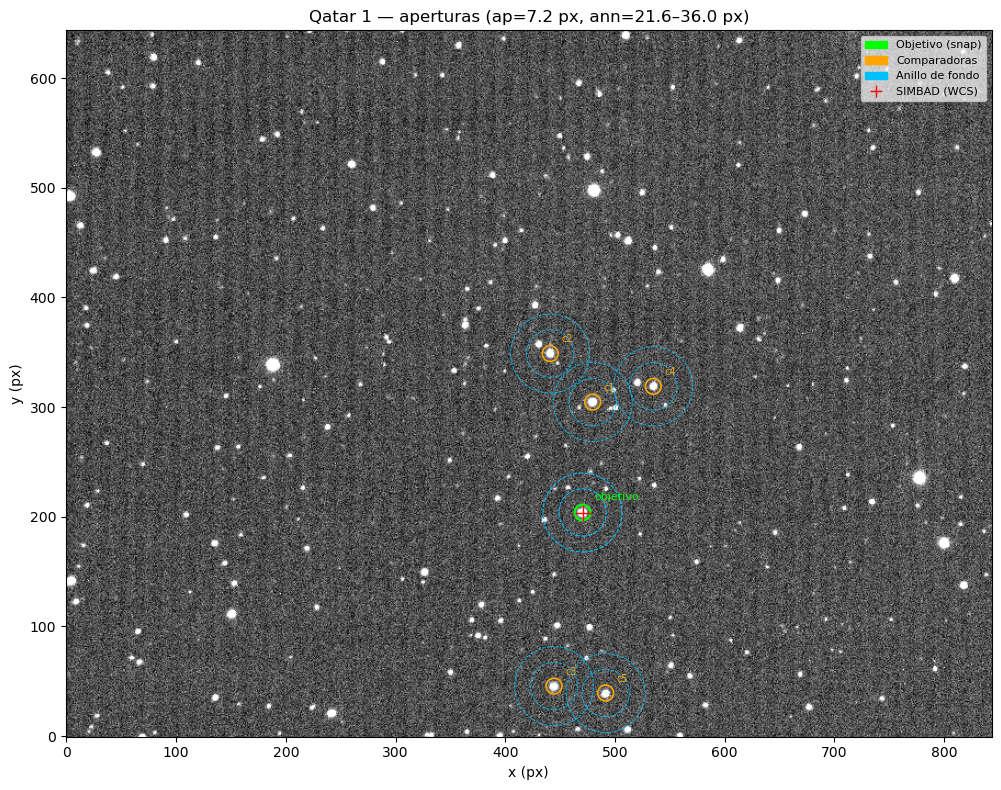

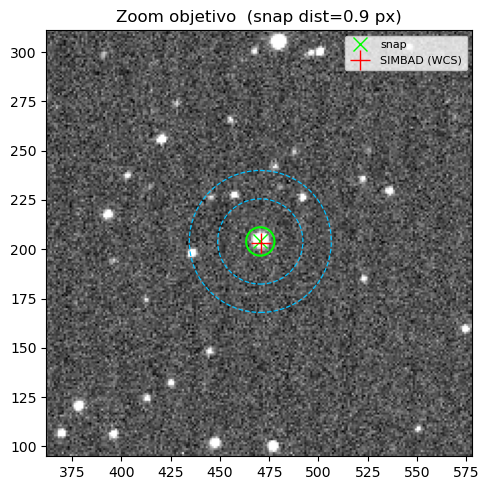

In [6]:
from numpy import median as np_median

# Calcular radios de apertura
fwhm_samples = [target_source.get('fwhm', config.detection_fwhm)]
fwhm_samples += [s.get('fwhm', config.detection_fwhm) for s in comparison_sources]
base_fwhm = float(np_median(fwhm_samples))
ap_r   = max(config.aperture_scale * base_fwhm, 2.0)
ann_r1 = max(config.annulus_scale_inner * ap_r, ap_r + 2.0)
ann_r2 = max(config.annulus_scale_outer * ap_r, ann_r1 + 2.0)

print(f"FWHM base      : {base_fwhm:.2f} px")
print(f"Apertura       : {ap_r:.2f} px")
print(f"Anillo interno : {ann_r1:.2f} px")
print(f"Anillo externo : {ann_r2:.2f} px")

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(ref_ccd.data)

# --- Vista global con aperturas ---
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(ref_ccd.data, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

for r, color, lw, ls in [(ap_r, 'lime', 1.5, '-'), (ann_r1, 'deepskyblue', 0.8, '--'), (ann_r2, 'deepskyblue', 0.8, '--')]:
    ax.add_patch(plt.Circle((target_source['x'], target_source['y']), r, color=color, fill=False, lw=lw, ls=ls))
ax.annotate('objetivo', xy=(target_source['x'], target_source['y']),
            xytext=(target_source['x'] + ap_r + 4, target_source['y'] + ap_r + 4),
            color='lime', fontsize=8, ha='left')

for i, c in enumerate(comparison_sources, 1):
    for r, color, lw, ls in [(ap_r, 'orange', 1.2, '-'), (ann_r1, 'deepskyblue', 0.6, '--'), (ann_r2, 'deepskyblue', 0.6, '--')]:
        ax.add_patch(plt.Circle((c['x'], c['y']), r, color=color, fill=False, lw=lw, ls=ls))
    ax.annotate(f'c{i}', xy=(c['x'], c['y']),
                xytext=(c['x'] + ap_r + 3, c['y'] + ap_r + 3),
                color='orange', fontsize=7, ha='left')

ax.plot(target_x, target_y, '+', color='red', ms=12, lw=1.5)
legend_handles = [
    mpatches.Patch(color='lime',        label='Objetivo (snap)'),
    mpatches.Patch(color='orange',      label='Comparadoras'),
    mpatches.Patch(color='deepskyblue', label='Anillo de fondo'),
    plt.Line2D([0], [0], marker='+', color='red', linestyle='None', ms=8, label='SIMBAD (WCS)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8, framealpha=0.7)
ax.set_title(f'{OBJECT_NAME} — aperturas (ap={ap_r:.1f} px, ann={ann_r1:.1f}–{ann_r2:.1f} px)')
ax.set_xlabel('x (px)')
ax.set_ylabel('y (px)')
plt.tight_layout()
plt.show()

# --- Zoom en la región del objetivo ---
ZOOM_R = max(int(ann_r2 * 3), 60)
tx, ty = int(target_source['x']), int(target_source['y'])
x0, x1 = max(tx - ZOOM_R, 0), min(tx + ZOOM_R, ref_ccd.data.shape[1])
y0, y1 = max(ty - ZOOM_R, 0), min(ty + ZOOM_R, ref_ccd.data.shape[0])

crop = ref_ccd.data[y0:y1, x0:x1]
vmin_z, vmax_z = zscale.get_limits(crop)

fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.imshow(crop, cmap='gray', vmin=vmin_z, vmax=vmax_z, origin='lower', extent=[x0, x1, y0, y1])
for r, color, lw, ls in [(ap_r, 'lime', 1.5, '-'), (ann_r1, 'deepskyblue', 0.9, '--'), (ann_r2, 'deepskyblue', 0.9, '--')]:
    ax2.add_patch(plt.Circle((target_source['x'], target_source['y']), r, color=color, fill=False, lw=lw, ls=ls))
ax2.plot(target_source['x'], target_source['y'], 'x', color='lime', ms=10, lw=1.5, label='snap')
ax2.plot(target_x, target_y, '+', color='red', ms=14, lw=1.5, label='SIMBAD (WCS)')
ax2.set_title(f'Zoom objetivo  (snap dist={snap_dist:.1f} px)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4 · Ejecución del pipeline completo

Genera `source_catalog.csv`, `aperture_photometry.csv` y `differential_light_curve.csv`.
Solo es necesario ejecutar esta celda una vez; las siguientes leen los CSV.

In [ ]:
import photometry.pipeline as phot_pipeline
importlib.reload(phot_pipeline)
from photometry.pipeline import PhotometryPaths, PhotometryConfig, run_photometry_pipeline

phot_paths = PhotometryPaths(
    aligned_dir=ALIGNED_DIR,
    output_dir=PHOT_DIR,
)
phot_config = PhotometryConfig(
    object_name=OBJECT_NAME,
    detection_fwhm=4.0,
    detection_threshold_sigma=3.0,
    max_comparisons=5,
    wcs_solver="online",      # API key desde os.environ (cargada en celda 1)
    persist_solved_wcs=True,
)

light_curve_table = run_photometry_pipeline(phot_paths, phot_config)
print(f"Puntos de curva de luz: {len(light_curve_table)}")
print(light_curve_table[:5])


## 5 · Curva de luz diferencial

Flujo relativo normalizado a la mediana. Un tránsito aparece como un descenso por debajo de 1.

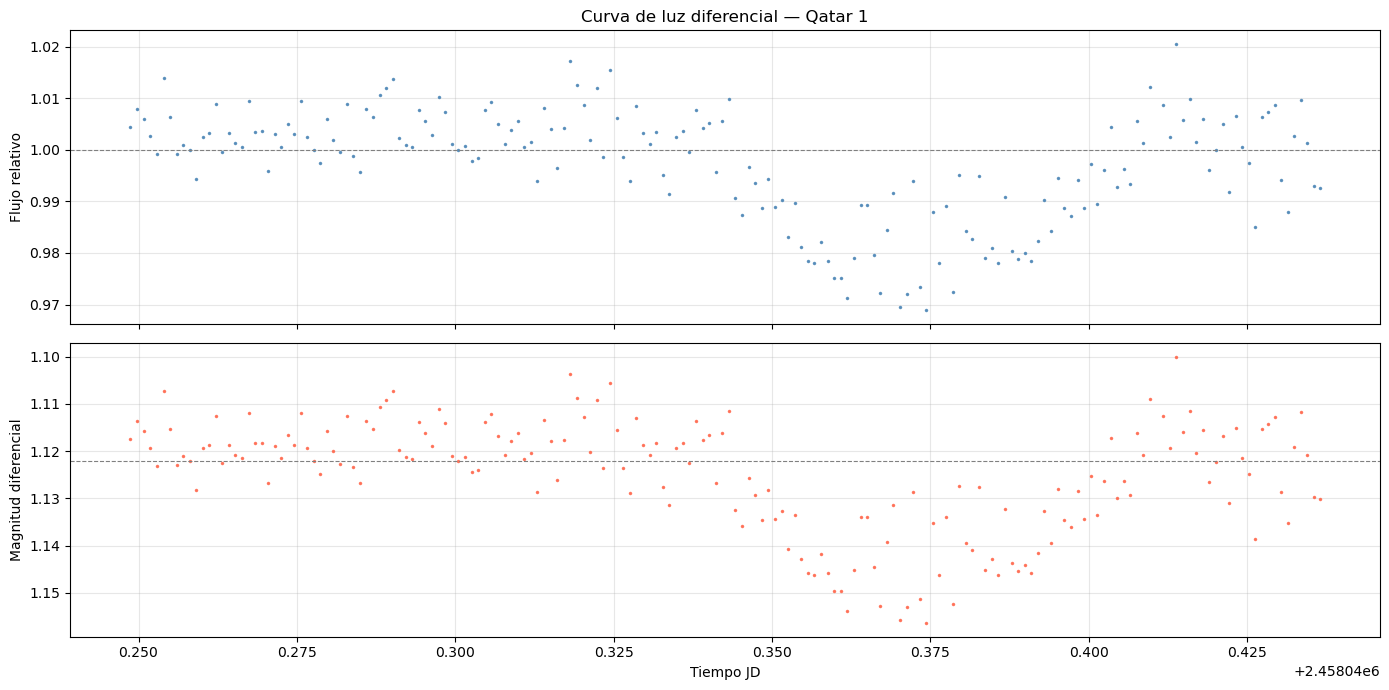

RMS del flujo relativo : 10.88 mmag
Puntos totales         : 181
Comparadoras usadas    : 5


In [8]:
lc = pd.read_csv(PHOT_DIR / 'differential_light_curve.csv')

time_col = 'time_jd' if 'time_jd' in lc.columns and lc['time_jd'].notna().any() else 'frame_index'
x_label  = 'Tiempo JD' if time_col == 'time_jd' else 'Índice de frame'

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(lc[time_col], lc['relative_flux'], '.', color='steelblue', ms=3, alpha=0.8)
axes[0].axhline(1.0, color='gray', lw=0.8, linestyle='--')
axes[0].set_ylabel('Flujo relativo')
axes[0].set_title(f'Curva de luz diferencial — {OBJECT_NAME}')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lc[time_col], lc['differential_mag'], '.', color='tomato', ms=3, alpha=0.8)
axes[1].axhline(lc['differential_mag'].median(), color='gray', lw=0.8, linestyle='--')
axes[1].invert_yaxis()
axes[1].set_ylabel('Magnitud diferencial')
axes[1].set_xlabel(x_label)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rms = float(lc['relative_flux'].std())
print(f"RMS del flujo relativo : {rms*1000:.2f} mmag")
print(f"Puntos totales         : {len(lc)}")
print(f"Comparadoras usadas    : {int(lc['n_comparisons_used'].mode()[0])}")

## 6 · Diagnóstico: flujo por comparadora

Comprueba que las comparadoras son estables entre sí. Una comparadora variable se detecta
porque su flujo individual no sigue el mismo patrón que el resto.

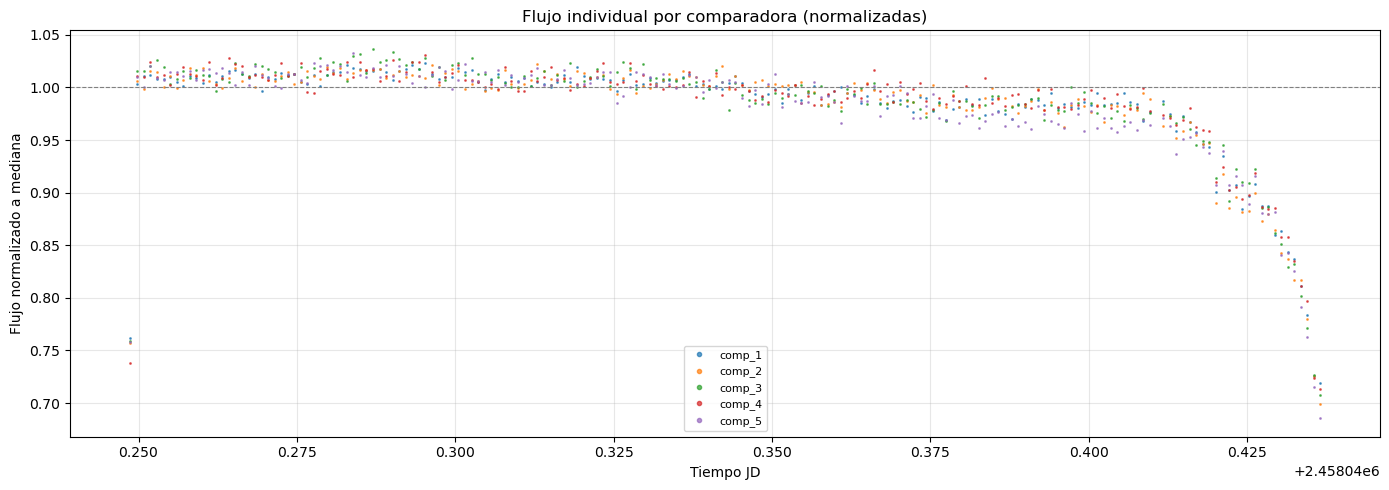

In [9]:
ap = pd.read_csv(PHOT_DIR / 'aperture_photometry.csv')
comp_data = ap[ap['role'] == 'comparison'].copy()

fig, ax = plt.subplots(figsize=(14, 5))
for source_id, group in comp_data.groupby('source_id'):
    norm_flux = group['net_flux'] / group['net_flux'].median()
    x_vals = group['time_jd'] if 'time_jd' in group.columns and group['time_jd'].notna().any() else group['frame_index']
    ax.plot(x_vals, norm_flux, '.', ms=2, alpha=0.7, label=source_id)

ax.axhline(1.0, color='gray', lw=0.8, linestyle='--')
ax.set_ylabel('Flujo normalizado a mediana')
ax.set_xlabel(x_label)
ax.set_title('Flujo individual por comparadora (normalizadas)')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()